Loading dataset: /content/TOTALSA.csv...
Starting training for all models...
Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Training GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Training Bi-LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


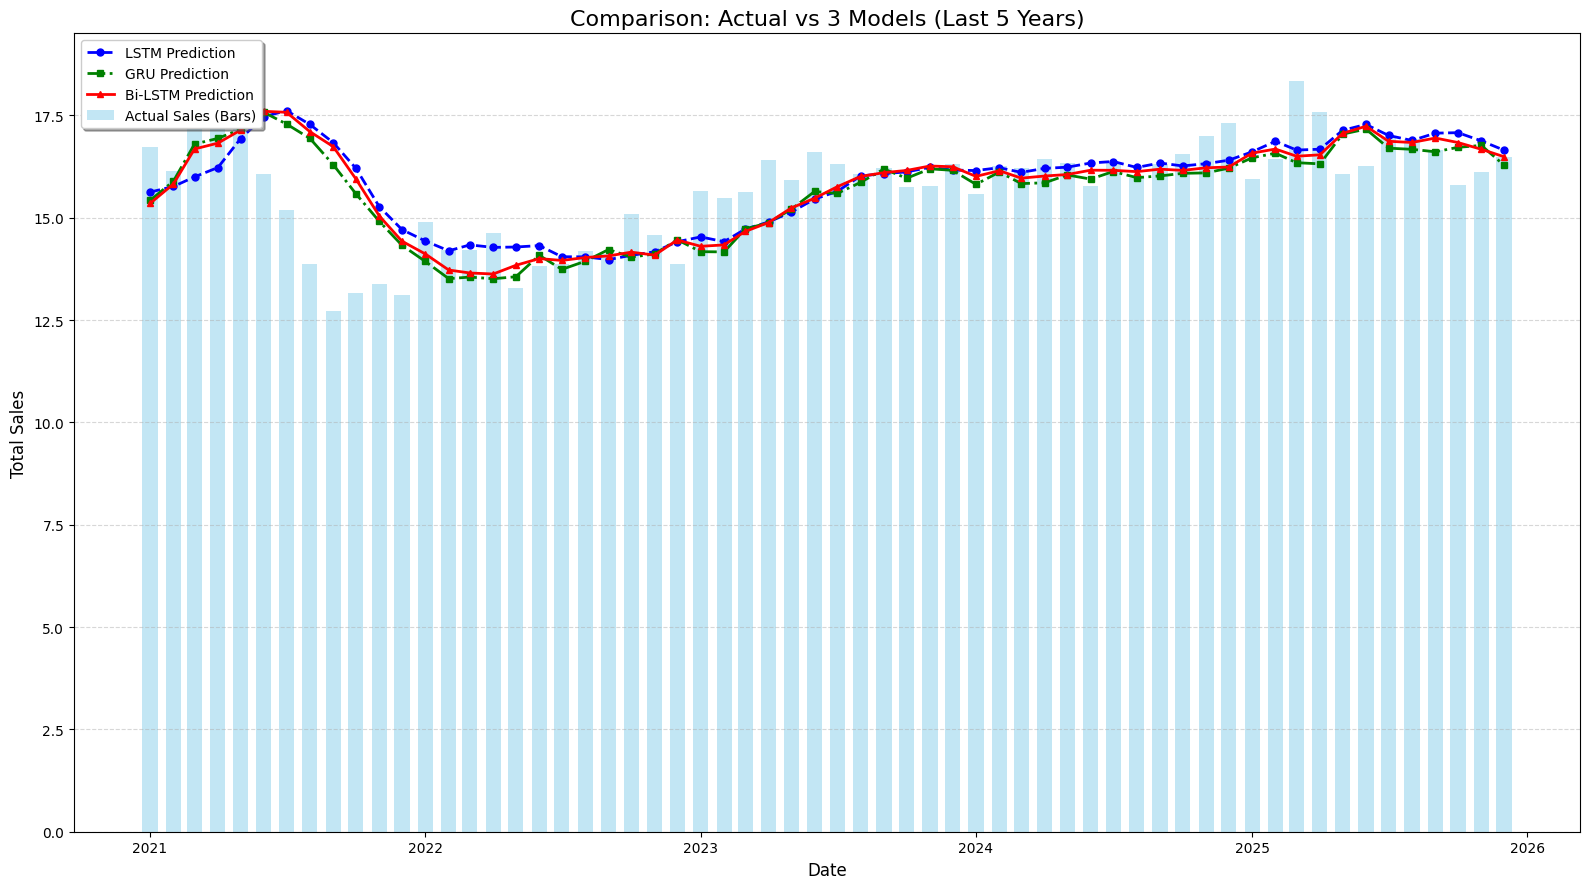

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional

# ---------------------------------------------------------
# 1. SETUP DATA
# ---------------------------------------------------------
filename = '/content/TOTALSA.csv'
print(f"Loading dataset: {filename}...")
df = pd.read_csv(filename, parse_dates=['observation_date'])

# Use the 'TOTALSA' column
data_values = df['TOTALSA'].values.astype('float32').reshape(-1, 1)

# Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(data_values)

# Split 80% Train, 20% Test
train_size = int(len(dataset) * 0.80)
train, test = dataset[0:train_size, :], dataset[train_size:len(dataset), :]

# Helper to create windows
def create_dataset(dataset, look_back=12):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

look_back = 12
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# Reshape for RNN
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

# ---------------------------------------------------------
# 2. TRAIN ALL 3 MODELS
# ---------------------------------------------------------
models_dict = {}
predictions_dict = {}
model_names = ['LSTM', 'GRU', 'Bi-LSTM']

print("Starting training for all models...")

for name in model_names:
    print(f"Training {name}...")
    model = Sequential()

    if name == 'LSTM':
        model.add(LSTM(50, input_shape=(1, look_back)))
    elif name == 'GRU':
        model.add(GRU(50, input_shape=(1, look_back)))
    elif name == 'Bi-LSTM':
        model.add(Bidirectional(LSTM(50), input_shape=(1, look_back)))

    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')

    # Train
    model.fit(trainX, trainY, epochs=20, batch_size=16, verbose=0)

    # Store the trained model in the dictionary
    models_dict[name] = model

    # Predict (Train and Test)
    trainP = model.predict(trainX)
    testP = model.predict(testX)

    # Invert and Store
    predictions_dict[name] = {
        'train': scaler.inverse_transform(trainP),
        'test': scaler.inverse_transform(testP)
    }

# ---------------------------------------------------------
# 3. PREPARE PLOTTING DATA
# ---------------------------------------------------------
# Inverse transform actual data for plotting
actual_data_inv = scaler.inverse_transform(dataset)

# create empty arrays to align plots with the timeline
def align_predictions(original_data, train_preds, test_preds, look_back):
    # Placeholders filled with NaN
    train_plot = np.empty_like(original_data)
    train_plot[:, :] = np.nan
    test_plot = np.empty_like(original_data)
    test_plot[:, :] = np.nan

    # Fill Train
    train_plot[look_back:len(train_preds)+look_back, :] = train_preds

    # Fill Test
    # Calculate start index based on training length
    start_test = len(train_preds) + (look_back * 2) + 1
    # Handle array size mismatch if any (slice to fit)
    limit = len(original_data) - start_test
    if len(test_preds) > limit:
        test_preds = test_preds[:limit]

    test_plot[start_test:start_test+len(test_preds), :] = test_preds

    return train_plot, test_plot

# ---------------------------------------------------------
# 4. VISUALIZATION (BARS + 3 MODEL LINES)
# ---------------------------------------------------------
plt.figure(figsize=(16, 9))

# 1. SETUP ZOOM (Last 5 Years = 60 Months)
# This fits best on a screen. If you want 10 years, change this to 10.
zoom_years = 5
zoom_idx = zoom_years * 12

# Get the dates and actual values for this period
dates_zoom = df['observation_date'][-zoom_idx:]
actual_zoom = actual_data_inv[-zoom_idx:].flatten() # Flatten for bar chart

# 2. PLOT ACTUAL DATA AS BARS
plt.bar(dates_zoom, actual_zoom, label='Actual Sales (Bars)', color='skyblue', alpha=0.5, width=20)

# 3. PLOT ALL 3 MODELS AS LINES
# We define specific colors and marker shapes to tell them apart easily
styles = {
    'LSTM':    {'color': 'blue',  'marker': 'o', 'linestyle': '--'},
    'GRU':     {'color': 'green', 'marker': 's', 'linestyle': '-.'},
    'Bi-LSTM': {'color': 'red',   'marker': '^', 'linestyle': '-'}
}

for name in model_names:
    # Get the test predictions for this model
    test_pred_full = predictions_dict[name]['test']

    # Extract only the last 60 months to match the zoom
    # We use [-zoom_idx:] to get the end of the array
    pred_zoom = test_pred_full[-zoom_idx:].flatten()

    # Plot the line
    plt.plot(dates_zoom, pred_zoom, label=f'{name} Prediction',
             color=styles[name]['color'],
             marker=styles[name]['marker'],
             linestyle=styles[name]['linestyle'],
             linewidth=2, markersize=5)

# 4. FORMATTING
plt.title(f'Comparison: Actual vs 3 Models (Last {zoom_years} Years)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


Generating future predictions for all models...


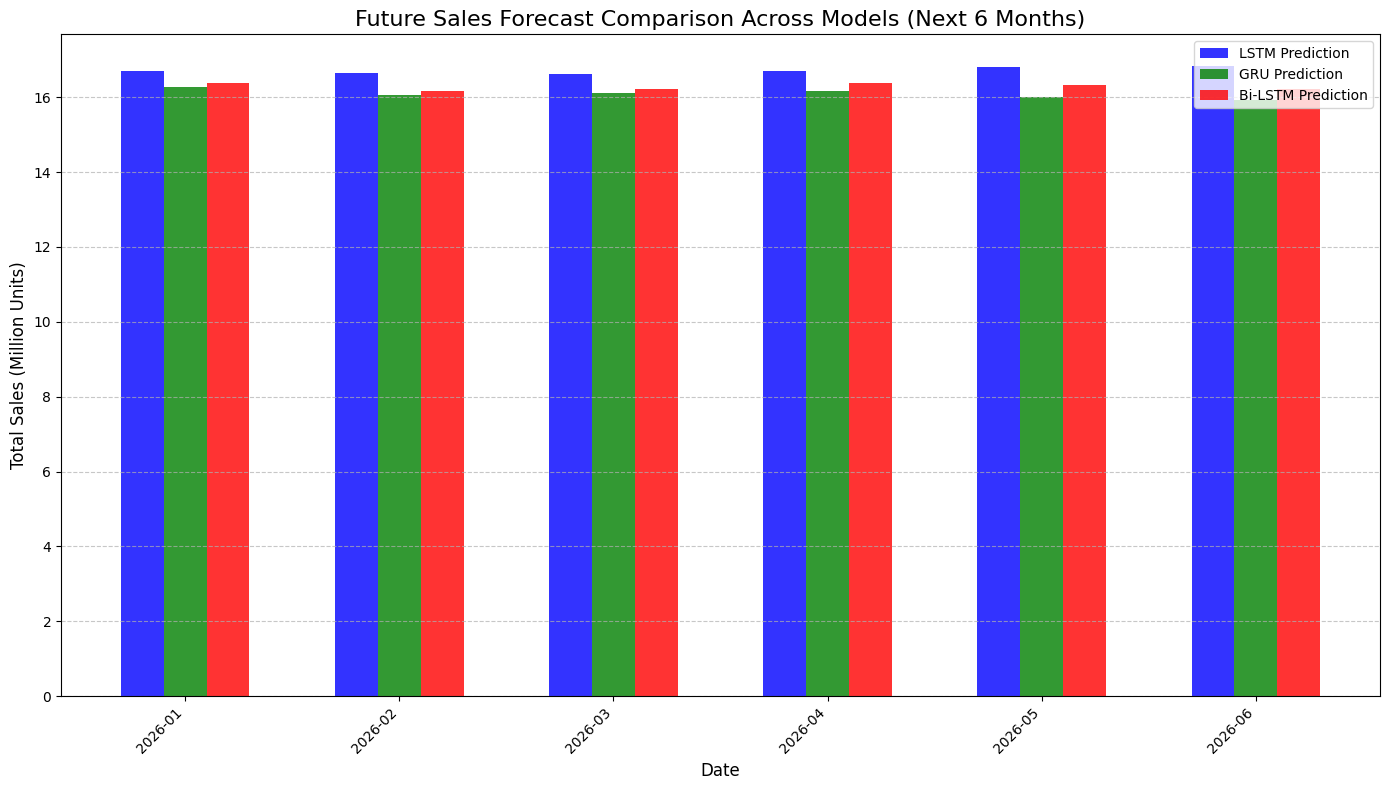

In [ ]:
# ---------------------------------------------------------
# COMPARING FUTURE PREDICTIONS OF ALL 3 MODELS
# ---------------------------------------------------------

future_predictions_all_models = {}

print("\nGenerating future predictions for all models...")

for model_name in model_names:
    model = models_dict[model_name]

    # Start with the last known data sequence
    last_sequence = dataset[-look_back:]
    curr_seq = last_sequence.reshape((1, 1, look_back))

    current_model_future_preds = []
    for i in range(6): # Predict next 6 months
        # Predict one step
        pred = model.predict(curr_seq, verbose=0)
        current_model_future_preds.append(pred[0,0])

        # Update sequence: remove first val, add new prediction at end
        new_seq_val = pred.reshape(1, 1, 1)
        curr_seq = np.append(curr_seq[:, :, 1:], new_seq_val, axis=2)

    # Invert scaling and store
    future_predictions_all_models[model_name] = scaler.inverse_transform(np.array(current_model_future_preds).reshape(-1, 1))

# Generate future dates for plotting
last_date = df['observation_date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=6, freq='MS')

# Prepare data for grouped bar chart
predictions_df = pd.DataFrame({
    'Date': future_dates,
    'LSTM': future_predictions_all_models['LSTM'].flatten(),
    'GRU': future_predictions_all_models['GRU'].flatten(),
    'Bi-LSTM': future_predictions_all_models['Bi-LSTM'].flatten()
})

# Plotting
plt.figure(figsize=(14, 8))

bar_width = 0.2
index = np.arange(len(future_dates))

plt.bar(index, predictions_df['LSTM'], bar_width, label='LSTM Prediction', color=styles['LSTM']['color'], alpha=0.8)
plt.bar(index + bar_width, predictions_df['GRU'], bar_width, label='GRU Prediction', color=styles['GRU']['color'], alpha=0.8)
plt.bar(index + 2 * bar_width, predictions_df['Bi-LSTM'], bar_width, label='Bi-LSTM Prediction', color=styles['Bi-LSTM']['color'], alpha=0.8)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (Million Units)', fontsize=12)
plt.title('Future Sales Forecast Comparison Across Models (Next 6 Months)', fontsize=16)
plt.xticks(index + bar_width, [date.strftime('%Y-%m') for date in future_dates], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

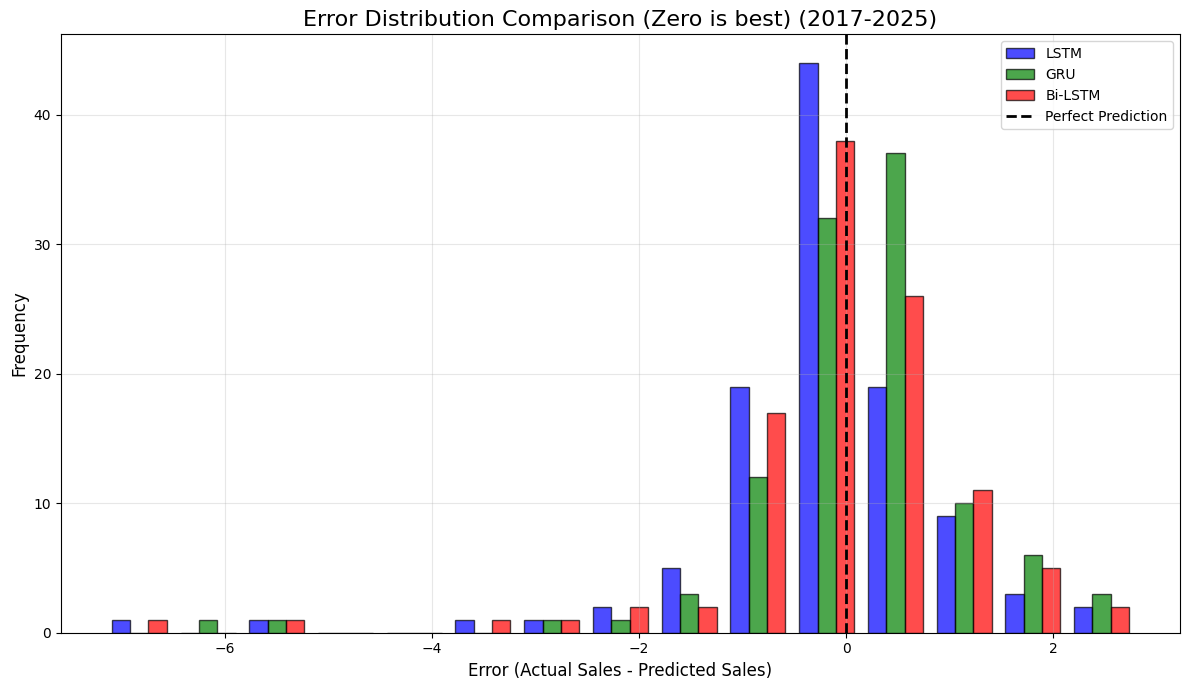

In [ ]:
# ---------------------------------------------------------
#  VISUALIZATION 2: ERROR DISTRIBUTION (ALL 3 MODELS)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

residuals_list = []
labels_list = []
# Colors matching the line chart above
colors_hist = ['blue', 'green', 'red']

# The actual values corresponding to the test predictions are in testY
actual_test_values_inv = scaler.inverse_transform(testY.reshape(-1, 1))


test_y_start_idx_df = train_size + look_back
test_y_end_idx_df = train_size + len(test) - 1 # Exclusive for iloc slicing
test_dates_for_errors = df['observation_date'].iloc[test_y_start_idx_df : test_y_end_idx_df]

min_year = test_dates_for_errors.dt.year.min()
max_year = test_dates_for_errors.dt.year.max()
year_range_str = f"({min_year}-{max_year})"

for name in model_names:
    # Get the test predictions for the current model
    model_test_predictions = predictions_dict[name]['test']

    # Error = Actual - Predicted
    error = actual_test_values_inv - model_test_predictions
    residuals_list.append(error.flatten())
    labels_list.append(name)

# Plot grouped histogram
plt.hist(residuals_list, bins=15, color=colors_hist, label=labels_list,
         edgecolor='black', alpha=0.7)

plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title(f'Error Distribution Comparison (Zero is best) {year_range_str}', fontsize=16)
plt.xlabel('Error (Actual Sales - Predicted Sales)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()